# Personal Budget

This notebook explores personal finance concepts.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === YOUR MONTHLY BUDGET ===
# After-tax monthly income
monthly_income = 6000

# Categorize every expense as Need, Want, or Savings
budget = {
    # NEEDS — survival stuff, can't avoid these
    'Rent':           1800,
    'Groceries':       400,
    'Utilities':       150,
    'Car Payment':     350,
    'Car Insurance':   120,
    'Health Insurance': 200,
    'Phone':            85,
    
    # WANTS — nice to have, could cut if needed
    'Dining Out':      250,
    'Subscriptions':    65,
    'Entertainment':   150,
    'Shopping':        200,
    'Gym':              50,
    
    # SAVINGS & DEBT — future you
    'Emergency Fund':  300,
    'Retirement 401k': 500,
    'Student Loan':    350,
    'Extra Savings':   100,
}

# Tag each expense
categories = {
    'Rent': 'Need', 'Groceries': 'Need', 'Utilities': 'Need',
    'Car Payment': 'Need', 'Car Insurance': 'Need', 
    'Health Insurance': 'Need', 'Phone': 'Need',
    'Dining Out': 'Want', 'Subscriptions': 'Want',
    'Entertainment': 'Want', 'Shopping': 'Want', 'Gym': 'Want',
    'Emergency Fund': 'Savings', 'Retirement 401k': 'Savings',
    'Student Loan': 'Savings', 'Extra Savings': 'Savings',
}

# Build the dataframe
df = pd.DataFrame({
    'Item': budget.keys(),
    'Amount': budget.values(),
    'Category': [categories[item] for item in budget.keys()]
})

# Summary by category
summary = df.groupby('Category')['Amount'].sum().reset_index()
summary['Percent'] = (summary['Amount'] / monthly_income * 100).round(1)
summary['Target'] = [50, 20, 30]  # Need=50, Savings=20, Want=30
summary['Difference'] = summary['Percent'] - summary['Target']

total_spent = df['Amount'].sum()
leftover = monthly_income - total_spent

print(f"Monthly Income:  ${monthly_income:,}")
print(f"Total Budgeted:  ${total_spent:,}")
print(f"Unallocated:     ${leftover:,}")
print(f"\n{'Category':<12} {'Spent':>8} {'Actual':>8} {'Target':>8} {'Diff':>8}")
print("-" * 48)
for _, row in summary.iterrows():
    diff_str = f"+{row['Difference']:.1f}%" if row['Difference'] > 0 else f"{row['Difference']:.1f}%"
    print(f"{row['Category']:<12} ${row['Amount']:>7,.0f} {row['Percent']:>7.1f}% {row['Target']:>7.0f}% {diff_str:>8}")
    

Monthly Income:  $6,000
Total Budgeted:  $5,070
Unallocated:     $930

Category        Spent   Actual   Target     Diff
------------------------------------------------
Need         $  3,105    51.7%      50%    +1.7%
Savings      $  1,250    20.8%      20%    +0.8%
Want         $    715    11.9%      30%   -18.1%


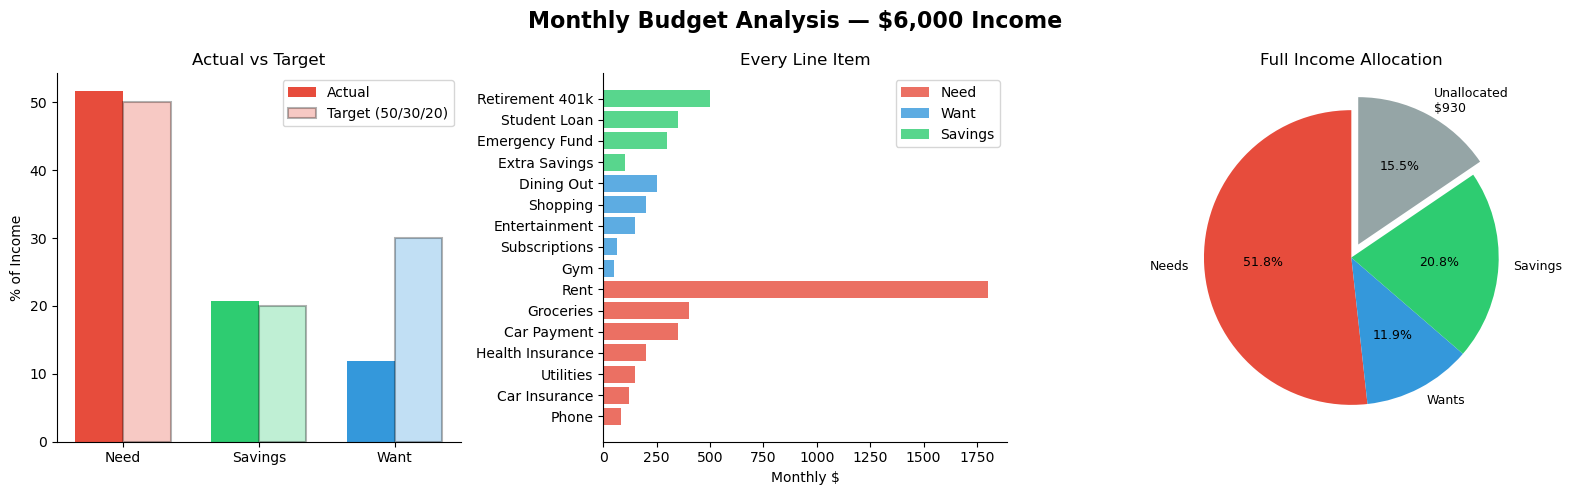

In [2]:
# === 50/30/20 Comparison Chart ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Monthly Budget Analysis — $6,000 Income', fontsize=16, fontweight='bold')

# --- Chart 1: Actual vs Target bar chart ---
ax1 = axes[0]
x = np.arange(len(summary))
width = 0.35
bars1 = ax1.bar(x - width/2, summary['Percent'], width, label='Actual', color=['#e74c3c', '#2ecc71', '#3498db'])
bars2 = ax1.bar(x + width/2, summary['Target'], width, label='Target (50/30/20)', color=['#e74c3c', '#2ecc71', '#3498db'], alpha=0.3, edgecolor='black', linewidth=1.5)
ax1.set_xticks(x)
ax1.set_xticklabels(summary['Category'])
ax1.set_ylabel('% of Income')
ax1.set_title('Actual vs Target')
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)

# --- Chart 2: Where every dollar goes (treemap-style horizontal bar) ---
ax2 = axes[1]
for cat, color in [('Need', '#e74c3c'), ('Want', '#3498db'), ('Savings', '#2ecc71')]:
    items = df[df['Category'] == cat].sort_values('Amount', ascending=True)
    ax2.barh(items['Item'], items['Amount'], color=color, alpha=0.8, label=cat)
ax2.set_xlabel('Monthly $')
ax2.set_title('Every Line Item')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

# --- Chart 3: The unallocated money problem ---
ax3 = axes[2]
sizes = [summary[summary['Category']=='Need']['Amount'].values[0],
         summary[summary['Category']=='Want']['Amount'].values[0],
         summary[summary['Category']=='Savings']['Amount'].values[0],
         leftover]
labels = ['Needs', 'Wants', 'Savings', f'Unallocated\n${leftover:,}']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']
explode = (0, 0, 0, 0.1)  # Pop out the unallocated slice
ax3.pie(sizes, labels=labels, colors=colors, explode=explode, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 9})
ax3.set_title('Full Income Allocation')

plt.tight_layout()
plt.savefig('../data/charts/budget_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

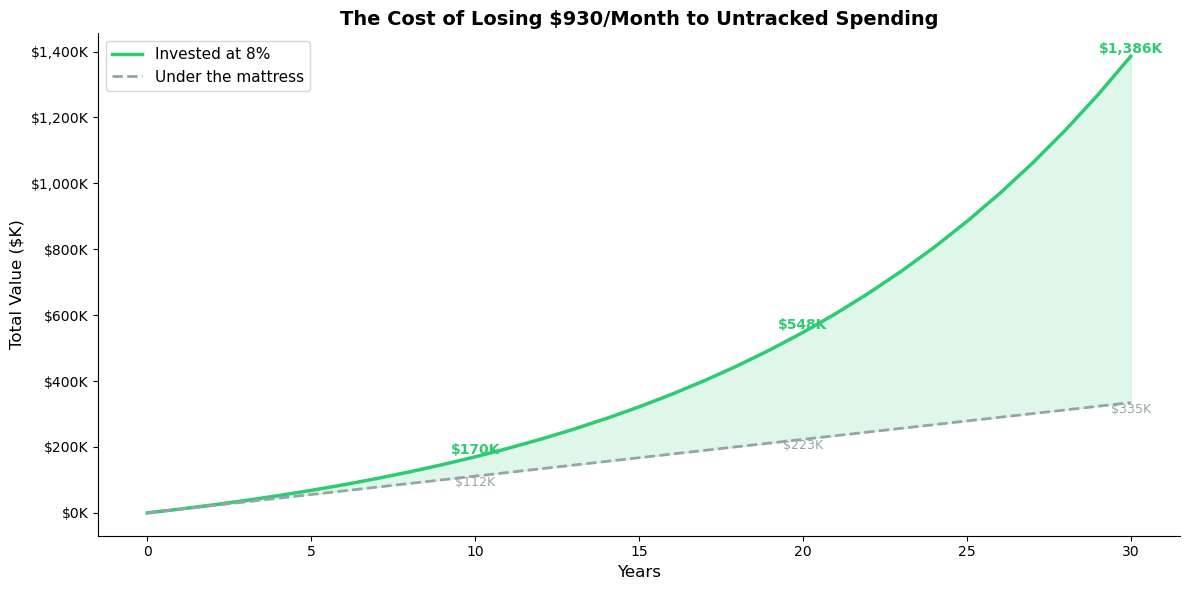


$930/month leaked over 30 years:
  Under the mattress: $     334,800
  Invested at 8%:     $   1,386,034
  Opportunity cost:   $   1,051,234


In [3]:
# === The Cost of Untracked Spending ===
# What if you captured that $930/month and invested it?

years = np.arange(0, 31)
monthly_leaked = leftover  # $930/month unallocated
annual_return = 0.08  # 8% average market return

# Future value of monthly investments: FV = PMT * [((1+r)^n - 1) / r]
monthly_rate = annual_return / 12
invested_value = []
mattress_value = []

for y in years:
    months = y * 12
    if months == 0:
        invested_value.append(0)
        mattress_value.append(0)
    else:
        fv = monthly_leaked * (((1 + monthly_rate)**months - 1) / monthly_rate)
        invested_value.append(fv)
        mattress_value.append(monthly_leaked * months)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(years, [v/1000 for v in invested_value], color='#2ecc71', linewidth=2.5, label='Invested at 8%')
ax.plot(years, [v/1000 for v in mattress_value], color='#95a5a6', linewidth=2, linestyle='--', label='Under the mattress')
ax.fill_between(years, [v/1000 for v in mattress_value], [v/1000 for v in invested_value], alpha=0.15, color='#2ecc71')

# Annotate key milestones
for y in [10, 20, 30]:
    inv = invested_value[y]
    cash = mattress_value[y]
    ax.annotate(f'${inv/1000:,.0f}K', xy=(y, inv/1000), fontsize=10, fontweight='bold', color='#2ecc71',
                ha='center', va='bottom')
    ax.annotate(f'${cash/1000:,.0f}K', xy=(y, cash/1000), fontsize=9, color='#95a5a6',
                ha='center', va='top')

ax.set_xlabel('Years', fontsize=12)
ax.set_ylabel('Total Value ($K)', fontsize=12)
ax.set_title(f'The Cost of Losing ${monthly_leaked:,}/Month to Untracked Spending', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}K'))

plt.tight_layout()
plt.savefig('../data/charts/untracked_spending_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n${monthly_leaked:,}/month leaked over 30 years:")
print(f"  Under the mattress: ${mattress_value[30]:>12,.0f}")
print(f"  Invested at 8%:     ${invested_value[30]:>12,.0f}")
print(f"  Opportunity cost:   ${invested_value[30] - mattress_value[30]:>12,.0f}")

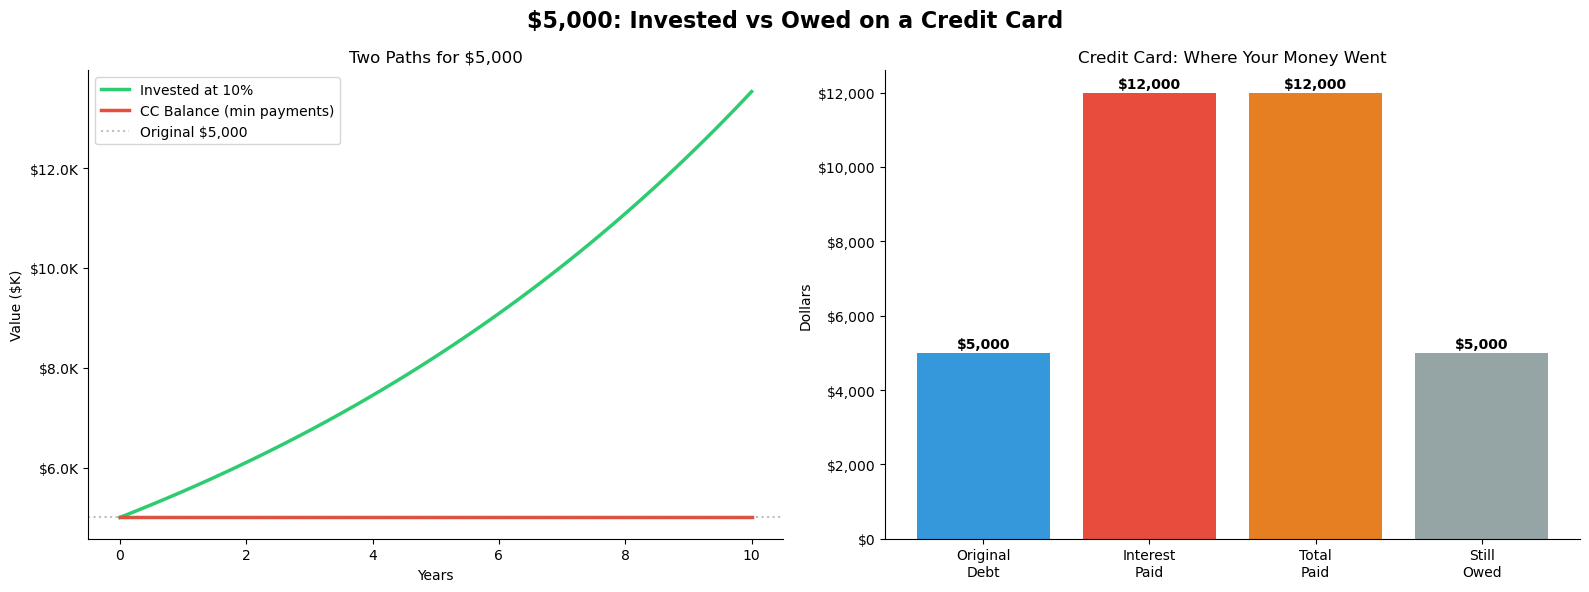


After 10 years:
  Investment grew to:    $    13,535
  CC balance remaining:  $     5,000
  CC total paid:         $    12,000
  CC interest paid:      $    12,000
  Net difference:        $     1,535


In [4]:
# === The Real Cost of Debt: Credit Card vs Investing ===
# Same $5,000 — one person invests it, one person owes it

principal = 5000
months = np.arange(0, 121)  # 10 years
cc_rate = 0.24 / 12     # 24% APR credit card
invest_rate = 0.10 / 12  # 10% annual market return
min_payment_pct = 0.02   # Minimum payment = 2% of balance

# --- Credit card: minimum payments only ---
cc_balance = [principal]
cc_total_paid = [0]
cc_interest_paid = [0]

for m in months[1:]:
    interest = cc_balance[-1] * cc_rate
    min_payment = max(cc_balance[-1] * min_payment_pct, 25)  # At least $25
    if cc_balance[-1] <= 0:
        cc_balance.append(0)
        cc_total_paid.append(cc_total_paid[-1])
        cc_interest_paid.append(cc_interest_paid[-1])
    else:
        new_balance = cc_balance[-1] + interest - min_payment
        cc_balance.append(max(new_balance, 0))
        cc_total_paid.append(cc_total_paid[-1] + min_payment)
        cc_interest_paid.append(cc_interest_paid[-1] + interest)

# --- Investment: same $5,000 growing ---
invest_value = [principal * (1 + invest_rate)**m for m in months]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('$5,000: Invested vs Owed on a Credit Card', fontsize=16, fontweight='bold')

# Left: The diverging paths
ax1 = axes[0]
ax1.plot(months/12, [v/1000 for v in invest_value], color='#2ecc71', linewidth=2.5, label='Invested at 10%')
ax1.plot(months/12, [b/1000 for b in cc_balance], color='#e74c3c', linewidth=2.5, label='CC Balance (min payments)')
ax1.axhline(y=5, color='gray', linestyle=':', alpha=0.5, label='Original $5,000')
ax1.set_xlabel('Years')
ax1.set_ylabel('Value ($K)')
ax1.set_title('Two Paths for $5,000')
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.1f}K'))

# Right: Where your credit card payments actually went
still_owing = cc_balance[-1]
total_interest = cc_interest_paid[-1]
total_principal_paid = cc_total_paid[-1] - total_interest
ax2 = axes[1]
bars = ax2.bar(['Original\nDebt', 'Interest\nPaid', 'Total\nPaid', 'Still\nOwed'],
               [principal, total_interest, cc_total_paid[-1], still_owing],
               color=['#3498db', '#e74c3c', '#e67e22', '#95a5a6'])
ax2.set_ylabel('Dollars')
ax2.set_title('Credit Card: Where Your Money Went')
ax2.spines[['top', 'right']].set_visible(False)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 50, f'${height:,.0f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../data/charts/debt_vs_invest.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAfter 10 years:")
print(f"  Investment grew to:    ${invest_value[-1]:>10,.0f}")
print(f"  CC balance remaining:  ${cc_balance[-1]:>10,.0f}")
print(f"  CC total paid:         ${cc_total_paid[-1]:>10,.0f}")
print(f"  CC interest paid:      ${cc_interest_paid[-1]:>10,.0f}")
print(f"  Net difference:        ${invest_value[-1] - cc_total_paid[-1]:>10,.0f}")

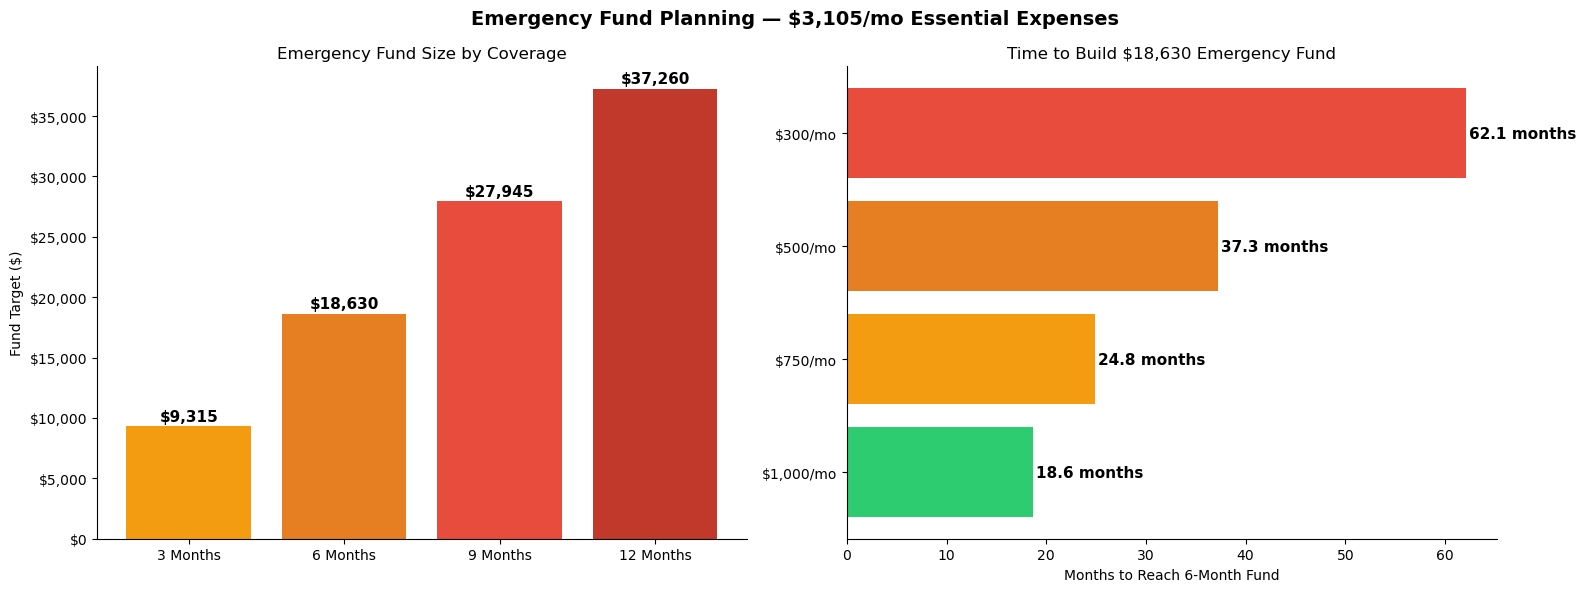


Monthly essential expenses (Needs): $3,105

Emergency fund targets:
   3 months: $     9,315
   6 months: $    18,630
   9 months: $    27,945
  12 months: $    37,260

At current savings rate ($300/mo):
  Time to 6-month fund: 62.1 months


In [5]:
# === Emergency Fund: How Much Runway Do You Need? ===
# Monthly essential expenses (Needs only — what you MUST pay even if you lose your job)

essential_expenses = df[df['Category'] == 'Need']['Amount'].sum()

# Different emergency fund targets
fund_months = [3, 6, 9, 12]
fund_amounts = [essential_expenses * m for m in fund_months]

# How long to build each fund at different savings rates
monthly_savings_options = [300, 500, 750, 1000]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Emergency Fund Planning — ${essential_expenses:,}/mo Essential Expenses', 
             fontsize=14, fontweight='bold')

# Left: How big should your emergency fund be?
ax1 = axes[0]
colors = ['#f39c12', '#e67e22', '#e74c3c', '#c0392b']
bars = ax1.bar([f'{m} Months' for m in fund_months], fund_amounts, color=colors)
for bar, amt in zip(bars, fund_amounts):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
             f'${amt:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_ylabel('Fund Target ($)')
ax1.set_title('Emergency Fund Size by Coverage')
ax1.spines[['top', 'right']].set_visible(False)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Right: How long to build a 6-month fund at different savings rates?
ax2 = axes[1]
target = essential_expenses * 6  # 6-month target
months_to_reach = [target / s for s in monthly_savings_options]
colors2 = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71']
bars2 = ax2.barh([f'${s:,}/mo' for s in monthly_savings_options], months_to_reach, color=colors2)
for bar, m in zip(bars2, months_to_reach):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2.,
             f'{m:.1f} months', va='center', fontweight='bold', fontsize=11)
ax2.set_xlabel('Months to Reach 6-Month Fund')
ax2.set_title(f'Time to Build ${target:,.0f} Emergency Fund')
ax2.spines[['top', 'right']].set_visible(False)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('../data/charts/emergency_fund.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMonthly essential expenses (Needs): ${essential_expenses:,}")
print(f"\nEmergency fund targets:")
for m, a in zip(fund_months, fund_amounts):
    print(f"  {m:>2} months: ${a:>10,.0f}")
print(f"\nAt current savings rate (${monthly_savings_options[0]:,}/mo):")
print(f"  Time to 6-month fund: {target/monthly_savings_options[0]:.1f} months")

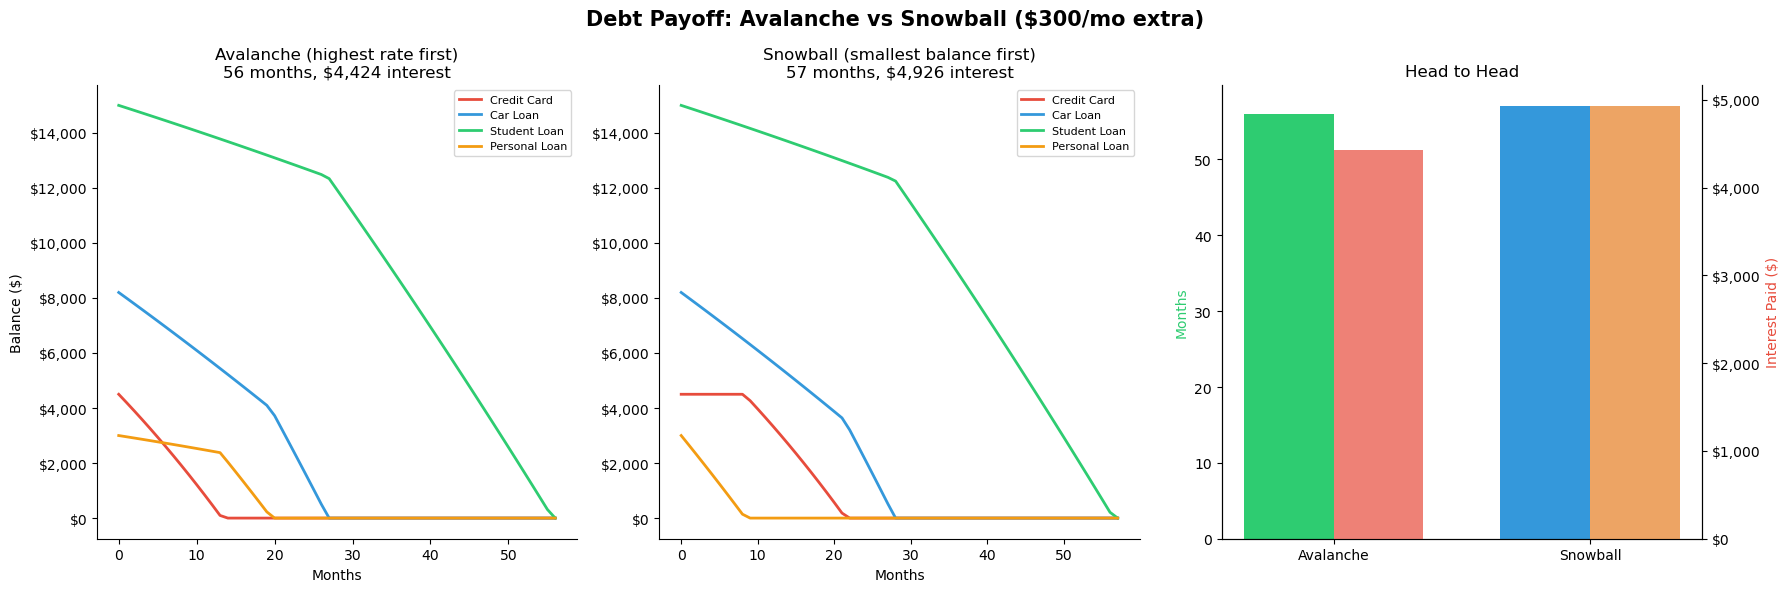


Metric                       Avalanche     Snowball   Difference
-----------------------------------------------------------------
Months to debt-free                 56           57            1
Total interest paid       $      4,424 $      4,926 $        502

Avalanche saves $502 in interest and 1 months.


In [6]:
# === Debt Payoff Strategies: Avalanche vs Snowball ===
# You have 4 debts. Same total. Two different strategies to pay them off.

debts = pd.DataFrame({
    'Name':    ['Credit Card', 'Car Loan', 'Student Loan', 'Personal Loan'],
    'Balance': [4500,          8200,       15000,          3000],
    'Rate':    [0.24,          0.065,      0.055,          0.12],
    'MinPay':  [90,            250,        160,            75],
})

extra_monthly = 300  # Extra money to throw at debt beyond minimums

def simulate_payoff(debts_df, strategy, extra):
    """Simulate month-by-month payoff for a given strategy."""
    balances = debts_df['Balance'].values.astype(float).copy()
    rates = debts_df['Rate'].values / 12
    mins = debts_df['MinPay'].values.astype(float).copy()
    names = debts_df['Name'].values
    
    history = [balances.copy()]
    total_interest = 0
    month = 0
    
    while balances.sum() > 0 and month < 360:  # 30 year safety cap
        month += 1
        
        # Apply interest
        interest = balances * rates
        interest = np.where(balances > 0, interest, 0)
        total_interest += interest.sum()
        balances += interest
        
        # Make minimum payments on all debts
        for i in range(len(balances)):
            if balances[i] > 0:
                payment = min(mins[i], balances[i])
                balances[i] -= payment
        
        # Apply extra payment to target debt
        remaining_extra = extra
        if strategy == 'avalanche':
            # Highest interest rate first
            order = np.argsort(-rates)
        else:
            # Smallest balance first
            order = np.argsort(balances)
            # Skip zero balances
            order = [i for i in order if balances[i] > 0]
        
        for i in order:
            if balances[i] > 0 and remaining_extra > 0:
                payment = min(remaining_extra, balances[i])
                balances[i] -= payment
                remaining_extra -= payment
        
        balances = np.maximum(balances, 0)
        history.append(balances.copy())
    
    return np.array(history), total_interest, month

# Run both strategies
hist_aval, interest_aval, months_aval = simulate_payoff(debts, 'avalanche', extra_monthly)
hist_snow, interest_snow, months_snow = simulate_payoff(debts, 'snowball', extra_monthly)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Debt Payoff: Avalanche vs Snowball (${extra_monthly}/mo extra)', fontsize=15, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Left: Avalanche
ax1 = axes[0]
for i, name in enumerate(debts['Name']):
    ax1.plot(range(len(hist_aval)), hist_aval[:, i], color=colors[i], linewidth=2, label=name)
ax1.set_title(f'Avalanche (highest rate first)\n{months_aval} months, ${interest_aval:,.0f} interest')
ax1.set_xlabel('Months')
ax1.set_ylabel('Balance ($)')
ax1.legend(fontsize=8)
ax1.spines[['top', 'right']].set_visible(False)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Middle: Snowball
ax2 = axes[1]
for i, name in enumerate(debts['Name']):
    ax2.plot(range(len(hist_snow)), hist_snow[:, i], color=colors[i], linewidth=2, label=name)
ax2.set_title(f'Snowball (smallest balance first)\n{months_snow} months, ${interest_snow:,.0f} interest')
ax2.set_xlabel('Months')
ax2.legend(fontsize=8)
ax2.spines[['top', 'right']].set_visible(False)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Right: Comparison summary
ax3 = axes[2]
x = np.arange(2)
width = 0.35
ax3.bar(x - width/2, [months_aval, months_snow], width, label='Months to Payoff', color=['#2ecc71', '#3498db'])
ax3.set_ylabel('Months', color='#2ecc71')
ax3.set_xticks(x)
ax3.set_xticklabels(['Avalanche', 'Snowball'])

ax3b = ax3.twinx()
ax3b.bar(x + width/2, [interest_aval, interest_snow], width, label='Total Interest', color=['#e74c3c', '#e67e22'], alpha=0.7)
ax3b.set_ylabel('Interest Paid ($)', color='#e74c3c')
ax3b.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

ax3.set_title('Head to Head')
ax3.spines[['top']].set_visible(False)
ax3b.spines[['top']].set_visible(False)

plt.tight_layout()
plt.savefig('../data/charts/debt_payoff_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

savings = interest_snow - interest_aval
print(f"\n{'Metric':<25} {'Avalanche':>12} {'Snowball':>12} {'Difference':>12}")
print("-" * 65)
print(f"{'Months to debt-free':<25} {months_aval:>12} {months_snow:>12} {months_snow - months_aval:>12}")
print(f"{'Total interest paid':<25} ${interest_aval:>11,.0f} ${interest_snow:>11,.0f} ${savings:>11,.0f}")
print(f"\nAvalanche saves ${savings:,.0f} in interest and {months_snow - months_aval} months.")

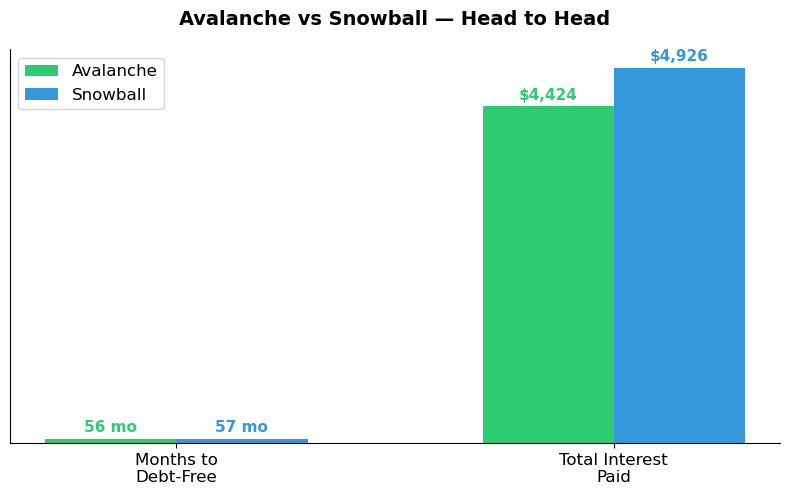

In [7]:
# === Fixed Head-to-Head Comparison ===
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Avalanche vs Snowball — Head to Head', fontsize=14, fontweight='bold')

metrics = ['Months to\nDebt-Free', 'Total Interest\nPaid']
avalanche_vals = [months_aval, interest_aval]
snowball_vals = [months_snow, interest_snow]

x = np.arange(len(metrics))
width = 0.3

bars1 = ax.bar(x - width/2, avalanche_vals, width, label='Avalanche', color='#2ecc71')
bars2 = ax.bar(x + width/2, snowball_vals, width, label='Snowball', color='#3498db')

# Label each bar with its value
for bar, val in zip(bars1, avalanche_vals):
    label = f'{val} mo' if val < 100 else f'${val:,.0f}'
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            label, ha='center', va='bottom', fontweight='bold', fontsize=11, color='#2ecc71')

for bar, val in zip(bars2, snowball_vals):
    label = f'{val} mo' if val < 100 else f'${val:,.0f}'
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            label, ha='center', va='bottom', fontweight='bold', fontsize=11, color='#3498db')

ax.legend(fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('')
ax.tick_params(left=False, labelleft=False)  # Hide y-axis — labels on bars are clearer

plt.tight_layout()
plt.savefig('../data/charts/debt_payoff_headtohead.png', dpi=150, bbox_inches='tight')
plt.show()

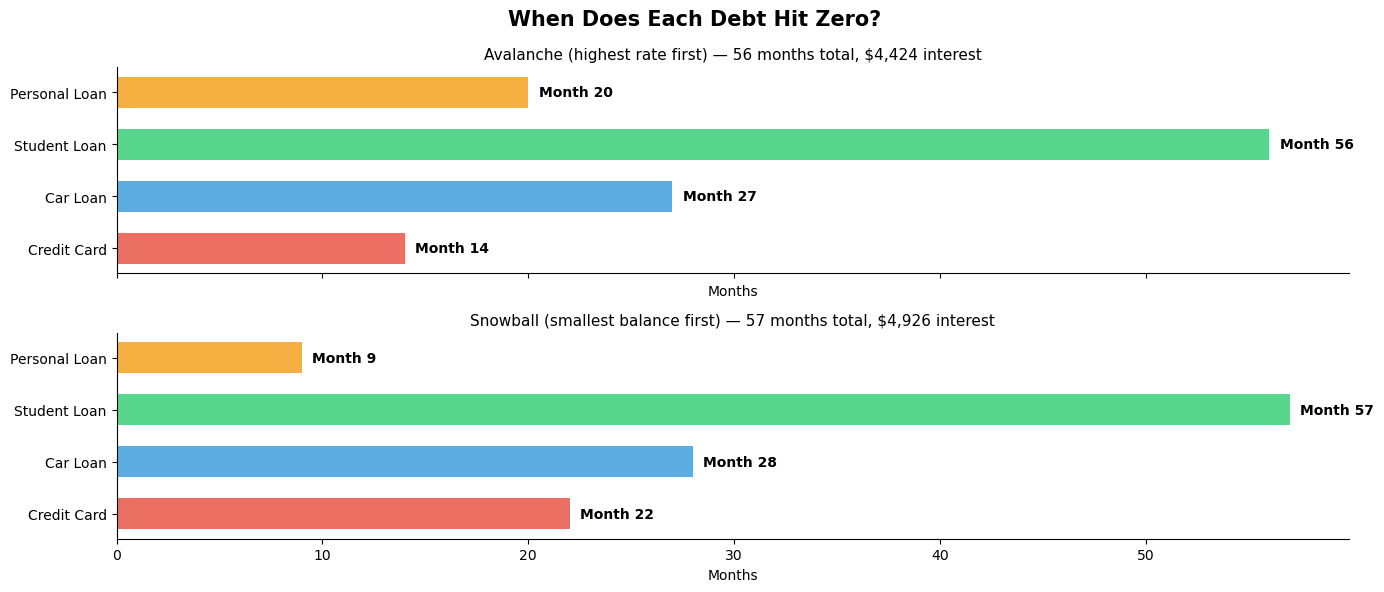

In [8]:
# === Debt Payoff: The Timeline View ===
# Show WHEN each debt dies under each strategy — that's the real story

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f'When Does Each Debt Hit Zero?', fontsize=15, fontweight='bold')

colors = {'Credit Card': '#e74c3c', 'Car Loan': '#3498db', 
          'Student Loan': '#2ecc71', 'Personal Loan': '#f39c12'}

for ax, hist, strategy, months_total, interest_total in [
    (axes[0], hist_aval, 'Avalanche (highest rate first)', months_aval, interest_aval),
    (axes[1], hist_snow, 'Snowball (smallest balance first)', months_snow, interest_snow)]:
    
    for i, name in enumerate(debts['Name']):
        # Find the month this debt hits zero
        balances = hist[:, i]
        payoff_month = next((m for m, b in enumerate(balances) if b <= 0), len(balances))
        
        ax.barh(name, payoff_month, color=colors[name], alpha=0.8, height=0.6)
        ax.text(payoff_month + 0.5, i, f'Month {payoff_month}', va='center', fontweight='bold', fontsize=10)
    
    ax.set_title(f'{strategy} — {months_total} months total, ${interest_total:,.0f} interest', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Months')

plt.tight_layout()
plt.savefig('../data/charts/debt_payoff_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# === Rent vs Buy Calculator — Core Logic ===
# The question: Over N years, is it cheaper to rent or buy?

def rent_vs_buy(monthly_rent, home_price, down_payment_pct, mortgage_rate, 
                years, annual_rent_increase=0.03, annual_appreciation=0.03,
                property_tax_rate=0.012, maintenance_pct=0.01,
                investment_return=0.08):
    """
    Compare total cost of renting vs buying over N years.
    Renter invests what they would have spent on a down payment + monthly savings.
    """
    down_payment = home_price * down_payment_pct
    loan_amount = home_price - down_payment
    monthly_rate = mortgage_rate / 12
    num_payments = years * 12
    
    # Monthly mortgage payment (fixed-rate)
    if monthly_rate > 0:
        mortgage_payment = loan_amount * (monthly_rate * (1 + monthly_rate)**num_payments) / \
                          ((1 + monthly_rate)**num_payments - 1)
    else:
        mortgage_payment = loan_amount / num_payments
    
    # Year-by-year simulation
    results = []
    rent = monthly_rent
    home_value = home_price
    remaining_loan = loan_amount
    
    # Renter invests the down payment on day 1
    renter_investments = down_payment
    
    total_rent = 0
    total_buy_cost = 0
    total_mortgage_interest = 0
    
    for year in range(1, years + 1):
        # --- RENTER ---
        annual_rent = rent * 12
        total_rent += annual_rent
        
        # Renter's monthly savings vs buyer's monthly costs
        monthly_property_tax = (home_value * property_tax_rate) / 12
        monthly_maintenance = (home_value * maintenance_pct) / 12
        buyer_monthly = mortgage_payment + monthly_property_tax + monthly_maintenance
        
        monthly_savings = buyer_monthly - rent  # Could be negative!
        if monthly_savings > 0:
            # Renter pays less, invests the difference
            for m in range(12):
                renter_investments *= (1 + investment_return/12)
                renter_investments += monthly_savings
        else:
            # Buyer pays less, renter dips into savings
            for m in range(12):
                renter_investments *= (1 + investment_return/12)
                renter_investments += monthly_savings  # Negative = withdrawing
        
        # --- BUYER ---
        annual_interest = 0
        for m in range(12):
            interest = remaining_loan * monthly_rate
            principal = mortgage_payment - interest
            remaining_loan -= principal
            annual_interest += interest
        
        annual_property_tax = home_value * property_tax_rate
        annual_maintenance = home_value * maintenance_pct
        annual_buy_cost = (mortgage_payment * 12) + annual_property_tax + annual_maintenance
        total_buy_cost += annual_buy_cost
        total_mortgage_interest += annual_interest
        
        # Home appreciates, rent increases
        home_value *= (1 + annual_appreciation)
        rent *= (1 + annual_rent_increase)
        
        # Buyer's equity = home value - remaining loan
        equity = home_value - max(remaining_loan, 0)
        
        results.append({
            'Year': year,
            'Annual_Rent': annual_rent,
            'Total_Rent': total_rent,
            'Renter_Net_Worth': renter_investments,
            'Annual_Buy_Cost': annual_buy_cost,
            'Total_Buy_Cost': total_buy_cost,
            'Home_Value': home_value,
            'Equity': equity,
            'Remaining_Loan': max(remaining_loan, 0),
            'Buyer_Monthly': buyer_monthly,
            'Renter_Monthly': annual_rent / 12,
        })
    
    return pd.DataFrame(results), mortgage_payment

# Run it with realistic DC-area numbers
results, mortgage_pmt = rent_vs_buy(
    monthly_rent=2000,
    home_price=450000,
    down_payment_pct=0.10,
    mortgage_rate=0.07,
    years=30,
)

print(f"Monthly mortgage payment: ${mortgage_pmt:,.0f}")
print(f"\nYear 1:  Rent ${results.iloc[0]['Renter_Monthly']:,.0f}/mo vs Buy ${results.iloc[0]['Buyer_Monthly']:,.0f}/mo")
print(f"Year 30: Rent ${results.iloc[-1]['Renter_Monthly']:,.0f}/mo vs Buy ${results.iloc[-1]['Buyer_Monthly']:,.0f}/mo")
print(f"\nAfter 30 years:")
print(f"  Renter net worth:  ${results.iloc[-1]['Renter_Net_Worth']:>12,.0f}")
print(f"  Buyer equity:      ${results.iloc[-1]['Equity']:>12,.0f}")
print(f"  Buyer total spent: ${results.iloc[-1]['Total_Buy_Cost']:>12,.0f}")
print(f"  Renter total spent:${results.iloc[-1]['Total_Rent']:>12,.0f}")

Monthly mortgage payment: $2,694

Year 1:  Rent $2,000/mo vs Buy $3,519/mo
Year 30: Rent $4,713/mo vs Buy $4,639/mo

After 30 years:
  Renter net worth:  $   2,159,379
  Buyer equity:      $   1,092,268
  Buyer total spent: $   1,441,008
  Renter total spent:$   1,141,810


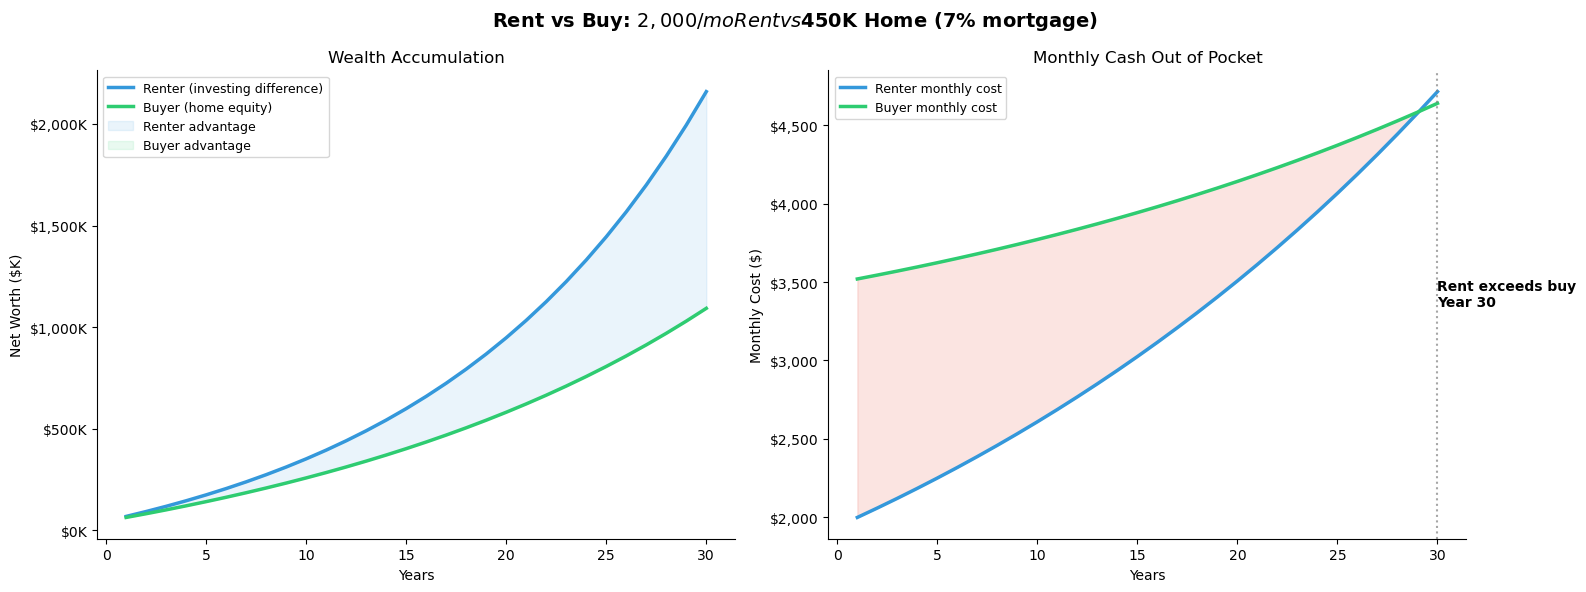

In [10]:
# === Rent vs Buy: The Crossover ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Rent vs Buy: $2,000/mo Rent vs $450K Home (7% mortgage)', fontsize=14, fontweight='bold')

# Left: Net worth trajectory — when does the buyer catch up?
ax1 = axes[0]
ax1.plot(results['Year'], results['Renter_Net_Worth']/1000, color='#3498db', linewidth=2.5, label='Renter (investing difference)')
ax1.plot(results['Year'], results['Equity']/1000, color='#2ecc71', linewidth=2.5, label='Buyer (home equity)')

# Find crossover point (if any)
renter_ahead = results['Renter_Net_Worth'] > results['Equity']
if not renter_ahead.all() and renter_ahead.any():
    cross_idx = renter_ahead.idxmin() if renter_ahead.iloc[0] else renter_ahead.idxmax()
    cross_year = results.loc[cross_idx, 'Year']
    cross_val = results.loc[cross_idx, 'Equity'] / 1000
    ax1.axvline(x=cross_year, color='gray', linestyle=':', alpha=0.7)
    ax1.annotate(f'Crossover\nYear {cross_year}', xy=(cross_year, cross_val),
                fontsize=10, ha='center', va='bottom', fontweight='bold')

ax1.fill_between(results['Year'], results['Equity']/1000, results['Renter_Net_Worth']/1000,
                 where=results['Renter_Net_Worth'] > results['Equity'], alpha=0.1, color='#3498db', label='Renter advantage')
ax1.fill_between(results['Year'], results['Equity']/1000, results['Renter_Net_Worth']/1000,
                 where=results['Renter_Net_Worth'] <= results['Equity'], alpha=0.1, color='#2ecc71', label='Buyer advantage')
ax1.set_xlabel('Years')
ax1.set_ylabel('Net Worth ($K)')
ax1.set_title('Wealth Accumulation')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}K'))

# Right: Monthly cost comparison — the squeeze
ax2 = axes[1]
ax2.plot(results['Year'], results['Renter_Monthly'], color='#3498db', linewidth=2.5, label='Renter monthly cost')
ax2.plot(results['Year'], results['Buyer_Monthly'], color='#2ecc71', linewidth=2.5, label='Buyer monthly cost')
ax2.fill_between(results['Year'], results['Renter_Monthly'], results['Buyer_Monthly'],
                 where=results['Buyer_Monthly'] > results['Renter_Monthly'], alpha=0.15, color='#e74c3c')

# Find when rent exceeds buyer cost
rent_higher = results[results['Renter_Monthly'] >= results['Buyer_Monthly']]
if not rent_higher.empty:
    flip_year = rent_higher.iloc[0]['Year']
    ax2.axvline(x=flip_year, color='gray', linestyle=':', alpha=0.7)
    ax2.annotate(f'Rent exceeds buy\nYear {int(flip_year)}', xy=(flip_year, results.iloc[0]['Buyer_Monthly']),
                fontsize=10, ha='left', va='top', fontweight='bold')

ax2.set_xlabel('Years')
ax2.set_ylabel('Monthly Cost ($)')
ax2.set_title('Monthly Cash Out of Pocket')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../data/charts/rent_vs_buy.png', dpi=150, bbox_inches='tight')
plt.show()

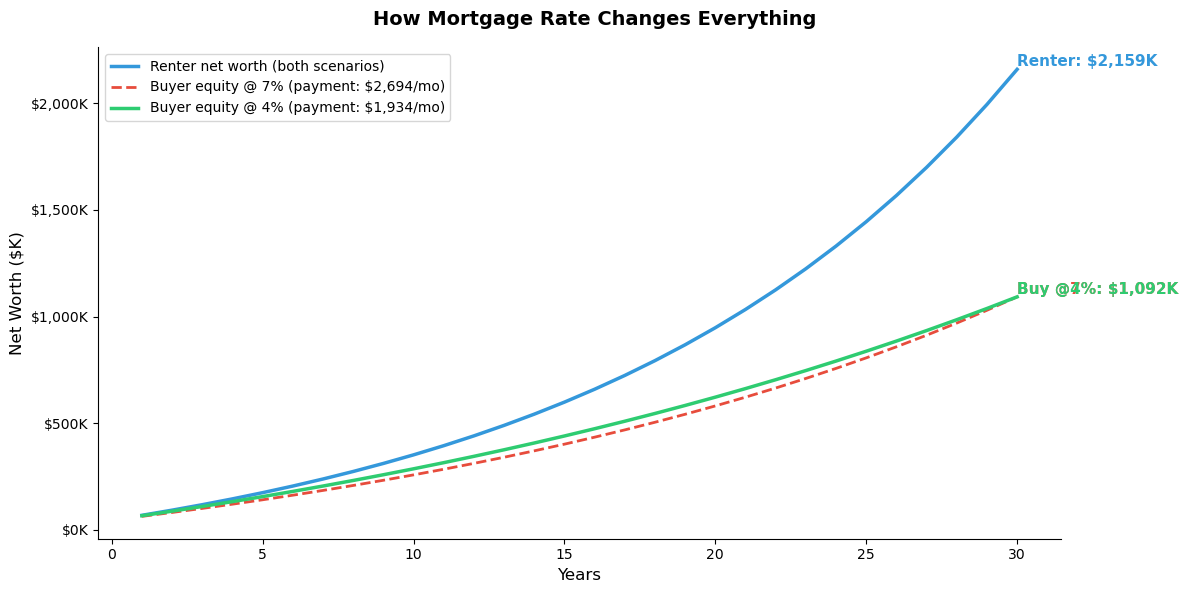


Scenario                  Monthly Payment  30-Year Equity
----------------------------------------------------------
Buy @ 7% mortgage         $         2,694 $     1,092,268
Buy @ 4% mortgage         $         1,934 $     1,092,268
Rent + invest                      $2,000 $     2,159,379


In [11]:
# === Same scenario, lower mortgage rate ===
results_low, mortgage_low = rent_vs_buy(
    monthly_rent=2000,
    home_price=450000,
    down_payment_pct=0.10,
    mortgage_rate=0.04,  # <-- Only change
    years=30,
)

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('How Mortgage Rate Changes Everything', fontsize=14, fontweight='bold')

# 7% scenario
ax.plot(results['Year'], results['Renter_Net_Worth']/1000, color='#3498db', linewidth=2.5, 
        label=f'Renter net worth (both scenarios)')
ax.plot(results['Year'], results['Equity']/1000, color='#e74c3c', linewidth=2, linestyle='--',
        label=f'Buyer equity @ 7% (payment: ${mortgage_pmt:,.0f}/mo)')

# 4% scenario  
ax.plot(results_low['Year'], results_low['Equity']/1000, color='#2ecc71', linewidth=2.5,
        label=f'Buyer equity @ 4% (payment: ${mortgage_low:,.0f}/mo)')

# Annotate endpoints
for label, val, color, y_offset in [
    ('Renter', results.iloc[-1]['Renter_Net_Worth'], '#3498db', 50),
    ('Buy @7%', results.iloc[-1]['Equity'], '#e74c3c', -80),
    ('Buy @4%', results_low.iloc[-1]['Equity'], '#2ecc71', 50),
]:
    ax.annotate(f'{label}: ${val/1000:,.0f}K', xy=(30, val/1000), fontsize=11, fontweight='bold',
                color=color, ha='left', va='bottom')

ax.set_xlabel('Years', fontsize=12)
ax.set_ylabel('Net Worth ($K)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}K'))

plt.tight_layout()
plt.savefig('../data/charts/rent_vs_buy_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Scenario':<25} {'Monthly Payment':>15} {'30-Year Equity':>15}")
print("-" * 58)
print(f"{'Buy @ 7% mortgage':<25} ${mortgage_pmt:>14,.0f} ${results.iloc[-1]['Equity']:>14,.0f}")
print(f"{'Buy @ 4% mortgage':<25} ${mortgage_low:>14,.0f} ${results_low.iloc[-1]['Equity']:>14,.0f}")
print(f"{'Rent + invest':<25} {'$2,000':>15} ${results.iloc[-1]['Renter_Net_Worth']:>14,.0f}")

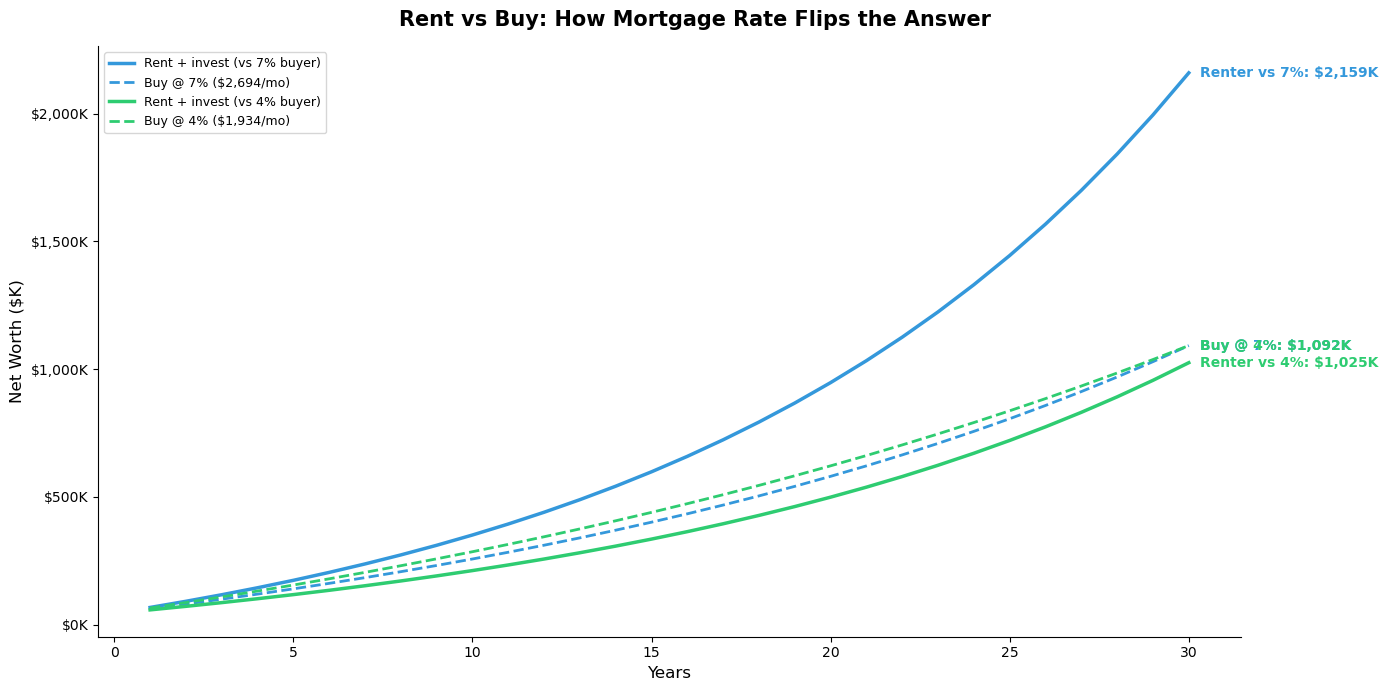


Scenario                  Monthly    Renter NW   Buyer Equity     Winner
------------------------------------------------------------------------
@ 7% mortgage          $    2,694 $  2,159,379 $    1,092,268     Renter
@ 4% mortgage          $    1,934 $  1,025,300 $    1,092,268      Buyer


In [12]:
# === Fixed: Each rate scenario gets its OWN renter ===
results_7, mort_7 = rent_vs_buy(monthly_rent=2000, home_price=450000, 
                                 down_payment_pct=0.10, mortgage_rate=0.07, years=30)
results_4, mort_4 = rent_vs_buy(monthly_rent=2000, home_price=450000, 
                                 down_payment_pct=0.10, mortgage_rate=0.04, years=30)

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Rent vs Buy: How Mortgage Rate Flips the Answer', fontsize=15, fontweight='bold')

# 7% scenario
ax.plot(results_7['Year'], results_7['Renter_Net_Worth']/1000, color='#3498db', linewidth=2.5, 
        label=f'Rent + invest (vs 7% buyer)')
ax.plot(results_7['Year'], results_7['Equity']/1000, color='#3498db', linewidth=2, linestyle='--',
        label=f'Buy @ 7% (${mort_7:,.0f}/mo)')

# 4% scenario
ax.plot(results_4['Year'], results_4['Renter_Net_Worth']/1000, color='#2ecc71', linewidth=2.5,
        label=f'Rent + invest (vs 4% buyer)')
ax.plot(results_4['Year'], results_4['Equity']/1000, color='#2ecc71', linewidth=2, linestyle='--',
        label=f'Buy @ 4% (${mort_4:,.0f}/mo)')

# Annotate endpoints clearly
annotations = [
    ('Renter vs 7%', results_7.iloc[-1]['Renter_Net_Worth'], '#3498db', 12),
    ('Buy @ 7%', results_7.iloc[-1]['Equity'], '#3498db', -12),
    ('Renter vs 4%', results_4.iloc[-1]['Renter_Net_Worth'], '#2ecc71', 12),
    ('Buy @ 4%', results_4.iloc[-1]['Equity'], '#2ecc71', -12),
]
for label, val, color, offset in annotations:
    ax.annotate(f'{label}: ${val/1000:,.0f}K', xy=(30.3, val/1000),
                fontsize=10, fontweight='bold', color=color, va='center')

ax.set_xlabel('Years', fontsize=12)
ax.set_ylabel('Net Worth ($K)', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}K'))

plt.tight_layout()
plt.savefig('../data/charts/rent_vs_buy_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Scenario':<22} {'Monthly':>10} {'Renter NW':>12} {'Buyer Equity':>14} {'Winner':>10}")
print("-" * 72)
r7 = results_7.iloc[-1]
r4 = results_4.iloc[-1]
w7 = 'Renter' if r7['Renter_Net_Worth'] > r7['Equity'] else 'Buyer'
w4 = 'Renter' if r4['Renter_Net_Worth'] > r4['Equity'] else 'Buyer'
print(f"{'@ 7% mortgage':<22} ${mort_7:>9,.0f} ${r7['Renter_Net_Worth']:>11,.0f} ${r7['Equity']:>13,.0f} {w7:>10}")
print(f"{'@ 4% mortgage':<22} ${mort_4:>9,.0f} ${r4['Renter_Net_Worth']:>11,.0f} ${r4['Equity']:>13,.0f} {w4:>10}")

In [13]:
# === rent_vs_buy.py — Preview in notebook before extracting ===
import argparse

def build_parser():
    parser = argparse.ArgumentParser(
        description='Rent vs Buy Calculator — Compare renting + investing vs buying a home'
    )
    parser.add_argument('--rent', type=float, required=True, help='Monthly rent ($)')
    parser.add_argument('--price', type=float, required=True, help='Home purchase price ($)')
    parser.add_argument('--down', type=float, default=0.10, help='Down payment %% as decimal (default: 0.10)')
    parser.add_argument('--rate', type=float, required=True, help='Mortgage interest rate as decimal (e.g., 0.07)')
    parser.add_argument('--years', type=int, default=30, help='Time horizon in years (default: 30)')
    parser.add_argument('--rent-increase', type=float, default=0.03, help='Annual rent increase (default: 0.03)')
    parser.add_argument('--appreciation', type=float, default=0.03, help='Annual home appreciation (default: 0.03)')
    parser.add_argument('--invest-return', type=float, default=0.08, help='Annual investment return (default: 0.08)')
    return parser

def run_analysis(args):
    """Core analysis — reuses logic from our notebook."""
    down_payment = args.price * args.down
    loan = args.price - down_payment
    monthly_rate = args.rate / 12
    n_payments = args.years * 12
    
    # Monthly mortgage
    if monthly_rate > 0:
        mortgage = loan * (monthly_rate * (1 + monthly_rate)**n_payments) / \
                   ((1 + monthly_rate)**n_payments - 1)
    else:
        mortgage = loan / n_payments
    
    # Simulate year by year
    rent = args.rent
    home_value = args.price
    remaining_loan = loan
    renter_investments = down_payment
    prop_tax_rate = 0.012
    maint_rate = 0.01
    
    for year in range(1, args.years + 1):
        # Buyer monthly costs
        monthly_tax = (home_value * prop_tax_rate) / 12
        monthly_maint = (home_value * maint_rate) / 12
        buyer_monthly = mortgage + monthly_tax + monthly_maint
        
        # Renter invests the difference
        monthly_diff = buyer_monthly - rent
        for m in range(12):
            renter_investments *= (1 + args.invest_return / 12)
            renter_investments += monthly_diff
        
        # Buyer pays down mortgage
        for m in range(12):
            interest = remaining_loan * monthly_rate
            principal = mortgage - interest
            remaining_loan -= principal
        
        home_value *= (1 + args.appreciation)
        rent *= (1 + args.rent_increase)
    
    equity = home_value - max(remaining_loan, 0)
    
    return {
        'mortgage_payment': mortgage,
        'buyer_monthly_yr1': mortgage + (args.price * prop_tax_rate / 12) + (args.price * maint_rate / 12),
        'renter_net_worth': renter_investments,
        'buyer_equity': equity,
        'home_value': home_value,
        'winner': 'Renter' if renter_investments > equity else 'Buyer',
        'margin': abs(renter_investments - equity),
    }

def display_results(args, results):
    print("\n" + "=" * 55)
    print("  RENT vs BUY ANALYSIS")
    print("=" * 55)
    print(f"\n  Rent:          ${args.rent:>10,.0f}/mo")
    print(f"  Home price:    ${args.price:>10,.0f}")
    print(f"  Down payment:  ${args.price * args.down:>10,.0f} ({args.down:.0%})")
    print(f"  Mortgage rate:     {args.rate:.2%}")
    print(f"  Time horizon:      {args.years} years")
    print(f"\n  Mortgage payment:  ${results['mortgage_payment']:>10,.0f}/mo")
    print(f"  Buyer total yr 1:  ${results['buyer_monthly_yr1']:>10,.0f}/mo")
    print(f"\n{'  AFTER ' + str(args.years) + ' YEARS':}")
    print(f"  {'-' * 40}")
    print(f"  Renter net worth:  ${results['renter_net_worth']:>12,.0f}")
    print(f"  Buyer equity:      ${results['buyer_equity']:>12,.0f}")
    print(f"  Home value:        ${results['home_value']:>12,.0f}")
    print(f"\n  >>> WINNER: {results['winner']} by ${results['margin']:,.0f}")
    print("=" * 55)

# Test it right here in the notebook
class MockArgs:
    rent=2000; price=450000; down=0.10; rate=0.07; years=30
    rent_increase=0.03; appreciation=0.03; invest_return=0.08

results = run_analysis(MockArgs())
display_results(MockArgs(), results)


  RENT vs BUY ANALYSIS

  Rent:          $     2,000/mo
  Home price:    $   450,000
  Down payment:  $    45,000 (10%)
  Mortgage rate:     7.00%
  Time horizon:      30 years

  Mortgage payment:  $     2,694/mo
  Buyer total yr 1:  $     3,519/mo

  AFTER 30 YEARS
  ----------------------------------------
  Renter net worth:  $   2,159,379
  Buyer equity:      $   1,092,268
  Home value:        $   1,092,268

  >>> WINNER: Renter by $1,067,111


## Try This to Drill the Concepts

- Change the `monthly_income` or one of the budget categories. Re-run the 50/30/20 chart. How close are you to the targets?
- In the untracked spending section, increase the daily leak amount and see the 30-year impact.
- For the debt payoff: Try different extra payments and compare avalanche vs snowball timelines.
- Experiment with the rent vs buy params (rate, appreciation, investment return) to find your personal breakeven.
